In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from mab.algorithms import ucb, exp3
from mab.environment.stationary.bernoulli import Bernoulli
from mab.environment.env import Agent
from mab.environment.experiment import Experiment
from mab.environment.plots import plot_regret

In [197]:
# Define the experiment parameters
n_arms = 5
time_horizon = int(1e5)
num_simulations = 1
delta = 0.1
mean1 = 0.3
bernoulli_probs = [mean1, mean1+delta, mean1+delta*2, mean1+delta*3, mean1+delta*4]  # True probabilities for each arm
env = Bernoulli(mean_rewards=bernoulli_probs, seed=42)

In [219]:
# Initialize the algorithms
exp3_agent = Agent(exp3.EXP3(n_arms=n_arms, seed=30, gamma=0.01))
exp3_loss_agent = Agent(exp3.EXP3Loss(n_arms=n_arms, seed=42, gamma=0.005))

In [220]:
algorithms = [exp3_agent, exp3_loss_agent]
args = {'store_rewards': True}

# Run the experiment
experiment = Experiment(env, algorithms, time_horizon, num_simulations)
experiment.run()

In [140]:
from mab.environment.stationary import utils

In [221]:
regret_exp3 = utils.cal_stochastic_regret(bernoulli_probs, exp3_agent.action_hist)
regret_exp3_loss = utils.cal_stochastic_regret(bernoulli_probs, exp3_loss_agent.action_hist)

In [222]:
regret_dict = {'exp3': regret_exp3, 'exp3_loss': regret_exp3_loss}

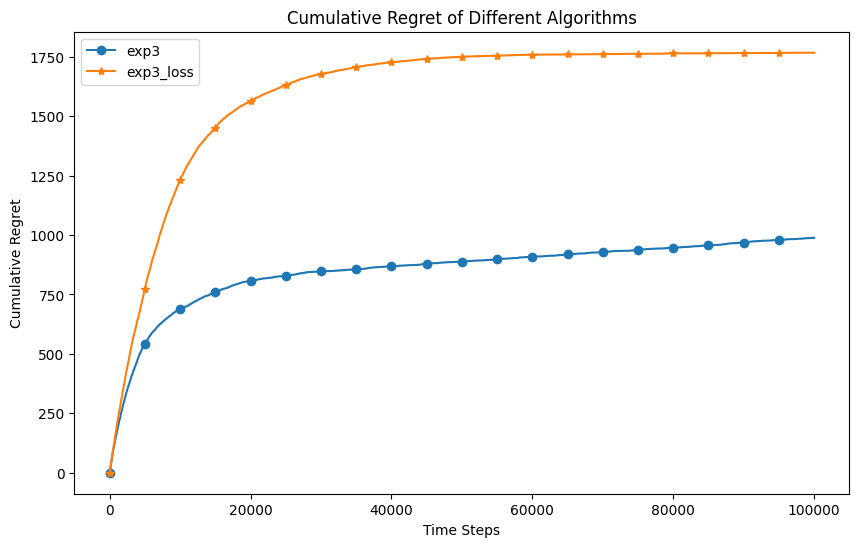

<Figure size 640x480 with 0 Axes>

In [223]:
regret_plot = plot_regret(regret_dict)

**Count Frequency**

In [81]:
from collections import Counter

In [213]:
print('Total arm counts (EXP3): ', Counter(exp3_agent.action_hist))
print('Total arm counts (EXP3 Loss): ', Counter(exp3_loss_agent.action_hist))

Total arm counts (EXP3):  Counter({4: 91654, 3: 2334, 2: 2098, 1: 2008, 0: 1906})
Total arm counts (EXP3 Loss):  Counter({4: 97957, 3: 1115, 2: 430, 0: 262, 1: 236})


In [110]:
exp3_agent.action_hist

array([0, 1, 1, ..., 1, 1, 1])